# Evaluación final SMB v2: degradación normalizada por pentagrama

Esta notebook ejecuta la evaluación final corregida. V1 se conserva como piloto de desarrollo: demostró que una degradación definida en píxeles absolutos no mantiene su severidad cuando cambia el tamaño del pentagrama. V2 usa 64 obras nuevas, una página por obra, y expresa el desenfoque como fracción de la separación entre líneas del pentagrama.

**Regla de lectura:** no se ajusta ningún parámetro con estas páginas ni con sus resultados. Si el preflight de escala falla, la ejecución se detiene antes de inferir modelos.

## 1. Preparación reproducible

En Kaggle, activa GPU e Internet, configura el secreto `HF_TOKEN` y ejecuta todas las celdas. El código reutiliza el PyTorch del runtime para no instalar una rueda CUDA incompatible.

In [2]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import random
import shutil
import subprocess
import sys
from datetime import UTC, datetime
from pathlib import Path

REPOSITORY_URL = "https://github.com/dreinon/proyecto-tfg.git"
IS_KAGGLE = Path("/kaggle/working").is_dir()


def discover_project_root() -> Path:
    starts = [Path.cwd(), Path("/kaggle/working/proyecto-tfg")]
    for start in starts:
        for candidate in (start, *start.parents):
            if (candidate / "pyproject.toml").is_file():
                return candidate.resolve()
    if not IS_KAGGLE:
        raise RuntimeError("No se encuentra el repositorio del proyecto.")
    if shutil.which("uv") is None:
        raise RuntimeError("El runtime de Kaggle no incluye uv.")
    destination = Path("/kaggle/working/proyecto-tfg")
    subprocess.run(["git", "clone", "--depth", "1", REPOSITORY_URL, str(destination)], check=True)
    return destination.resolve()


PROJECT_ROOT = discover_project_root()
if IS_KAGGLE:
    torch_before = subprocess.run(
        [sys.executable, "-c", "import torch; print(torch.__version__)"],
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
    subprocess.run(
        ["uv", "pip", "install", "--system", "--no-deps", "-e", str(PROJECT_ROOT)],
        check=True,
    )
    subprocess.run(
        [
            "uv",
            "pip",
            "install",
            "--system",
            "--no-deps",
            "cairosvg==2.9.0",
            "cairocffi==1.7.1",
            "cssselect2==0.9.0",
            "defusedxml==0.7.1",
            "tinycss2==1.5.1",
            "webencodings==0.5.1",
        ],
        check=True,
    )
    subprocess.run(
        [
            "uv",
            "pip",
            "install",
            "--system",
            "--no-deps",
            "verovio==6.2.1",
            "spandrel==0.4.2",
            "einops==0.8.2",
        ],
        check=True,
    )
    torch_after = subprocess.run(
        [sys.executable, "-c", "import torch; print(torch.__version__)"],
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
    if torch_after != torch_before:
        raise RuntimeError("La preparación reemplazó PyTorch; reinicia el runtime.")
    subprocess.run(
        [
            sys.executable,
            "-c",
            "import PIL, torchvision, spandrel; import cairocffi, cssselect2, cairosvg",
        ],
        check=True,
    )

source_path = str(PROJECT_ROOT / "src")
if source_path not in sys.path:
    sys.path.insert(0, source_path)
os.chdir(PROJECT_ROOT)
PROJECT_ROOT

Using Python 3.12.13 environment at: /usr
Resolved 1 package in 53ms
Prepared 1 package in 639ms
Installed 1 package in 1ms
 + score-super-resolution==0.1.0 (from file:///kaggle/working/proyecto-tfg)
Using Python 3.12.13 environment at: /usr
Resolved 6 packages in 94ms
Prepared 4 packages in 44ms
Uninstalled 1 package in 2ms
Installed 4 packages in 5ms
 + cairocffi==1.7.1
 + cairosvg==2.9.0
 + cssselect2==0.9.0
 - tinycss2==1.4.0
 + tinycss2==1.5.1
Using Python 3.12.13 environment at: /usr
Resolved 3 packages in 169ms
Prepared 2 packages in 589ms
Installed 2 packages in 68ms
 + spandrel==0.4.2
 + verovio==6.2.1


PosixPath('/kaggle/working/proyecto-tfg')

In [3]:
if IS_KAGGLE:
    from kaggle_secrets import UserSecretsClient

    os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import FileLink, display

from score_super_resolution.benchmark_policy import BenchmarkPurpose, BenchmarkState
from score_super_resolution.comparison import (
    as_rgb8,
    ensure_manifest_generation,
    fidelity_metrics,
    technical_smoke_image,
)
from score_super_resolution.contracts import validate_instance
from score_super_resolution.degradation import align_reference
from score_super_resolution.pretrained import MODEL_METHODS, PretrainedSRRunner
from score_super_resolution.smb import check_access, load_smb
from score_super_resolution.smb_audit import resolve_active_manifest
from score_super_resolution.staff_scale import (
    CONDITIONS,
    apply_scale_normalized_degradation,
    canonical_smb_pixel_sha256,
    load_evaluation_sample_v2,
    load_scale_normalized_control,
)

SEED = 20260830
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

EXPERIMENT_PATH = PROJECT_ROOT / "configs/experiments/smb-pretrained-evaluation-v2.yaml"
UNLOCK_PATH = PROJECT_ROOT / "configs/smb-evaluation-v2/unlock.json"
GENERATION_ROOT = ensure_manifest_generation(PROJECT_ROOT)
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts/phase3-smb-evaluation-v2"
RESULTS_PATH = ARTIFACT_ROOT / "raw-metrics.csv"
TRACES_PATH = ARTIFACT_ROOT / "degradation-traces.jsonl"
PREFLIGHT_PATH = ARTIFACT_ROOT / "staff-scale-preflight.csv"

experiment = yaml.safe_load(EXPERIMENT_PATH.read_text(encoding="utf-8"))
sample = load_evaluation_sample_v2(PROJECT_ROOT)
degradation = load_scale_normalized_control(PROJECT_ROOT)
qualitative_assignment = tuple(tuple(row) for row in experiment["qualitative"]["assignment"])
evaluation_unlocked = experiment["status"] == "frozen" and UNLOCK_PATH.is_file()
run_smb_evaluation = IS_KAGGLE or os.environ.get("RUN_SMB_EVALUATION_V2") == "1"
evaluation_ready = evaluation_unlocked and run_smb_evaluation

{
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "seed": SEED,
    "sample_pages": len(sample),
    "sample_works": len({row.source_group_id for row in sample}),
    "degradation_control_sha256": degradation.sha256,
    "evaluation_ready": evaluation_ready,
}

{'python': '3.12.13',
 'torch': '2.10.0+cu128',
 'cuda_runtime': '12.8',
 'device': 'Tesla T4',
 'seed': 20260830,
 'sample_pages': 64,
 'sample_works': 64,
 'degradation_control_sha256': '69e80f8884746cfe61b2e52e75bccc9a4cf78e929f37de0b9805a90f3ea0d809',
 'evaluation_ready': True}

## 2. Datos y preflight de identidad

Las separaciones de pentagrama se midieron antes de congelar la muestra y se conservan en su CSV. Antes de inferir, esta celda demuestra que cada imagen reproduce el hash canónico de píxeles, las dimensiones, el índice y la obra del manifiesto auditado. Así se verifican exactamente los inputs sin depender de que diferentes versiones de OpenCV repitan el detector de líneas.

In [5]:
access = check_access()
sample_frame = pd.DataFrame([row.__dict__ for row in sample])
display(
    sample_frame["staff_spacing_px"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame()
)
pd.DataFrame(
    [
        {
            "repository": access.get("repository_id"),
            "revision": access.get("resolved_revision"),
            "access_status": access.get("status"),
            "descriptor_match": access.get("descriptor_match"),
            "sample_pages": len(sample_frame),
            "independent_works": sample_frame.source_group_id.nunique(),
        }
    ]
)

README.md: 0.00B [00:00, ?B/s]

,staff_spacing_px
count,64.000000
mean,10.414960
std,2.769686
min,6.525932
10%,8.465918
25%,9.060543
50%,9.996175
75%,10.201334
90%,14.901918
max,18.275336


,repository,revision,access_status,descriptor_match,sample_pages,independent_works
0,PRAIG/SMB,96332e8c4ac81cbdb7f61093ec5a4bfff76a0adb,accessible,True,64,64


In [6]:
if not evaluation_ready:
    reason = (
        "falta el desbloqueo científico"
        if not evaluation_unlocked
        else "ejecución local desactivada; usa Kaggle o RUN_SMB_EVALUATION_V2=1"
    )
    print(f"Evaluación SMB v2 no iniciada: {reason}.")
    dataset = None
else:
    unlock = json.loads(UNLOCK_PATH.read_text(encoding="utf-8"))
    dataset = load_smb(
        purpose=BenchmarkPurpose.INFERENCE,
        state=BenchmarkState.EVALUATION_UNLOCKED,
        unlock_record=unlock,
        project_root=PROJECT_ROOT,
        manifest_generation_root=GENERATION_ROOT,
    )
    print(f"SMB cargado en la revisión fijada: {len(dataset)} páginas.")

data/test-00000-of-00001.parquet:   0%|          | 0.00/367M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/685 [00:00<?, ? examples/s]

SMB cargado en la revisión fijada: 685 páginas.


In [7]:
preflight = pd.DataFrame()
if dataset is not None:
    _, manifest_rows = resolve_active_manifest(
        active_path=PROJECT_ROOT / "data/manifests/smb-evaluation-v1.yaml",
        generation_root=GENERATION_ROOT,
    )
    manifest_by_item = {row["item_id"]: row for row in manifest_rows}
    preflight_records = []
    for row in sample:
        source = dataset[row.upstream_index]
        source_image = source["image"]
        manifest_row = manifest_by_item[row.item_id]
        observed_pixel_sha256 = canonical_smb_pixel_sha256(source_image)
        expected_pixel_sha256 = manifest_row["image"]["pixel_sha256"]
        observed_width, observed_height = source_image.size
        identity_match = (
            observed_pixel_sha256 == expected_pixel_sha256
            and manifest_row["upstream_index"] == row.upstream_index
            and manifest_row["source_group_id"] == row.source_group_id
            and manifest_row["image"]["decoded_width"] == observed_width
            and manifest_row["image"]["decoded_height"] == observed_height
        )
        preflight_records.append(
            {
                "upstream_index": row.upstream_index,
                "item_id": row.item_id,
                "source_group_id": row.source_group_id,
                "frozen_staff_spacing_px": row.staff_spacing_px,
                "expected_pixel_sha256": expected_pixel_sha256,
                "observed_pixel_sha256": observed_pixel_sha256,
                "width": observed_width,
                "height": observed_height,
                "identity_match": identity_match,
            }
        )
    preflight = pd.DataFrame(preflight_records)
    if len(preflight) != 64 or not preflight["identity_match"].all():
        raise RuntimeError("El preflight v2 no coincide con el manifiesto auditado.")
    ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
    preflight.to_csv(PREFLIGHT_PATH, index=False)
    print(
        {
            "pages": len(preflight),
            "works": preflight.source_group_id.nunique(),
            "canonical_pixel_hashes": preflight.observed_pixel_sha256.nunique(),
            "status": "manifest-identity-passed-before-inference",
        }
    )
else:
    print("Preflight SMB pendiente de la ejecución autorizada.")

{'pages': 64, 'works': 64, 'canonical_pixel_hashes': 64, 'status': 'manifest-identity-passed-before-inference'}


## 3. Métodos y prueba técnica

Solo después de superar el preflight se verifican los checkpoints y la compatibilidad del acelerador.

In [8]:
runner = None
smoke_results = pd.DataFrame()
if dataset is not None:
    if IS_KAGGLE and not torch.cuda.is_available():
        raise RuntimeError("Activa un acelerador GPU en Kaggle antes de continuar.")
    if torch.cuda.is_available():
        capability = torch.cuda.get_device_capability(0)
        supported = torch.cuda.get_arch_list()
        torch.zeros(1, device="cuda")
        print({"gpu_capability": capability, "torch_architectures": supported})

    runner = PretrainedSRRunner(
        PROJECT_ROOT,
        tile_size=int(experiment["inference"]["tile_size"]),
        tile_overlap=int(experiment["inference"]["tile_overlap"]),
    )
    checkpoint_paths = runner.prepare()
    smoke_hr = technical_smoke_image()
    smoke_rows = []
    for scale in (2, 4):
        smoke_lr = cv2.resize(
            smoke_hr,
            (smoke_hr.shape[1] // scale, smoke_hr.shape[0] // scale),
            interpolation=cv2.INTER_AREA,
        )
        for method_id in MODEL_METHODS:
            output = runner.run(
                method_id,
                smoke_lr,
                target_shape=smoke_hr.shape,
                condition_id=f"x{scale}-clean",
            )
            smoke_rows.append(
                {
                    "scale": scale,
                    "method_id": method_id,
                    "shape_ok": output.pixels.shape == smoke_hr.shape,
                    "runtime_seconds": output.elapsed_ns / 1e9,
                    "parameters": output.evidence.get("parameter_count"),
                }
            )
    smoke_results = pd.DataFrame(smoke_rows)
smoke_results

{'gpu_capability': (7, 5), 'torch_architectures': ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']}


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


,scale,method_id,shape_ok,runtime_seconds,parameters
0,2,bicubic-opencv-v1,True,0.021341,NaN
1,2,edsr-baseline-official-v1,True,0.663052,1369883.0
2,2,swinir-lightweight-official-v1,True,0.171967,910152.0
3,4,bicubic-opencv-v1,True,0.000066,NaN
4,4,edsr-baseline-official-v1,True,0.007565,1517595.0
5,4,swinir-lightweight-official-v1,True,0.038216,929628.0


El smoke test solo valida la tubería técnica con una imagen sintética; no constituye evidencia musical ni interviene en las conclusiones.

## 4. Evaluación v2

La ejecución es reanudable por página. Guarda 1152 tuplas (64 páginas × 6 condiciones × 3 métodos), 384 trazas de degradación y las comparaciones cualitativas preasignadas.

In [9]:
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
results = pd.read_csv(RESULTS_PATH) if RESULTS_PATH.is_file() else pd.DataFrame()
expected_columns = {
    "upstream_index",
    "item_id",
    "source_group_id",
    "condition_id",
    "scale",
    "profile",
    "staff_spacing_px",
    "effective_blur_sigma_px",
    "method_id",
    "psnr_y",
    "ssim_y",
    "psnr_rgb",
    "ssim_rgb",
    "runtime_seconds",
    "degradation_trace_id",
    "output_sha256",
    "checkpoint_sha256",
}
if not results.empty and set(results.columns) != expected_columns:
    raise RuntimeError("El CSV parcial v2 no tiene el contrato esperado; no se mezclará.")

if dataset is not None:
    completed = (
        set()
        if results.empty
        else set(zip(results.item_id, results.condition_id, results.method_id, strict=True))
    )
    records = results.to_dict("records") if not results.empty else []
    trace_records = []
    qualitative_lookup = dict(qualitative_assignment)

    for row in sample:
        source = dataset[row.upstream_index]
        hr_original = as_rgb8(source["image"])
        for condition_id in CONDITIONS:
            scale = int(condition_id[1])
            degraded = apply_scale_normalized_degradation(
                hr_original,
                control=degradation,
                condition_id=condition_id,
                item_id=row.item_id,
                source_group_id=row.source_group_id,
                staff_spacing_px=row.staff_spacing_px,
            )
            validate_instance("staff-scale-degradation-trace", degraded.trace, version=1)
            trace_records.append(degraded.trace)
            reference = align_reference(hr_original, scale).pixels
            blur_operations = [
                operation
                for operation in degraded.trace["operations"]
                if operation["operator_id"] == "staff-scale-gaussian-blur"
            ]
            effective_blur_sigma_px = (
                blur_operations[0]["effective_sigma_px"] if blur_operations else 0.0
            )

            output_dir = None
            if qualitative_lookup.get(row.item_id) == condition_id:
                output_dir = ARTIFACT_ROOT / "qualitative" / row.item_id / condition_id
                output_dir.mkdir(parents=True, exist_ok=True)
                cv2.imwrite(
                    str(output_dir / "reference-hr.png"),
                    cv2.cvtColor(reference, cv2.COLOR_RGB2BGR),
                )
                nearest = cv2.resize(
                    degraded.pixels,
                    (reference.shape[1], reference.shape[0]),
                    interpolation=cv2.INTER_NEAREST,
                )
                cv2.imwrite(
                    str(output_dir / "input-lr-nearest.png"),
                    cv2.cvtColor(nearest, cv2.COLOR_RGB2BGR),
                )

            for method_id in MODEL_METHODS:
                key = (row.item_id, condition_id, method_id)
                if key in completed:
                    continue
                reconstruction = runner.run(
                    method_id,
                    degraded.pixels,
                    target_shape=reference.shape,
                    condition_id=condition_id,
                )
                records.append(
                    {
                        "upstream_index": row.upstream_index,
                        "item_id": row.item_id,
                        "source_group_id": row.source_group_id,
                        "condition_id": condition_id,
                        "scale": scale,
                        "profile": condition_id.split("-", 1)[1],
                        "staff_spacing_px": row.staff_spacing_px,
                        "effective_blur_sigma_px": effective_blur_sigma_px,
                        "method_id": method_id,
                        **fidelity_metrics(reference, reconstruction.pixels),
                        "runtime_seconds": reconstruction.elapsed_ns / 1e9,
                        "degradation_trace_id": degraded.trace["trace_id"],
                        "output_sha256": reconstruction.evidence["output_pixel_sha256"],
                        "checkpoint_sha256": reconstruction.evidence.get("checkpoint_sha256"),
                    }
                )
                if output_dir is not None:
                    cv2.imwrite(
                        str(output_dir / f"{method_id}.png"),
                        cv2.cvtColor(reconstruction.pixels, cv2.COLOR_RGB2BGR),
                    )
        results = pd.DataFrame(records)
        temporary = RESULTS_PATH.with_suffix(".csv.tmp")
        results.to_csv(temporary, index=False)
        os.replace(temporary, RESULTS_PATH)

    trace_records.sort(key=lambda value: (value["item_id"], value["condition_id"]))
    temporary_traces = TRACES_PATH.with_suffix(".jsonl.tmp")
    temporary_traces.write_text(
        "".join(json.dumps(trace, sort_keys=True) + "\n" for trace in trace_records),
        encoding="utf-8",
    )
    os.replace(temporary_traces, TRACES_PATH)
    print(
        {
            "tuples": len(results),
            "expected_tuples": len(sample) * len(CONDITIONS) * len(MODEL_METHODS),
            "traces": len(trace_records),
        }
    )
results.head() if not results.empty else results

{'tuples': 1152, 'expected_tuples': 1152, 'traces': 384}


,upstream_index,item_id,source_group_id,condition_id,scale,profile,staff_spacing_px,effective_blur_sigma_px,method_id,psnr_y,ssim_y,psnr_rgb,ssim_rgb,runtime_seconds,degradation_trace_id,output_sha256,checkpoint_sha256
0,282,smb-test-000282,scarlatti_l016k306,x2-clean,2,clean,10.952297,0.000000,bicubic-opencv-v1,19.892116,0.882950,18.570195,0.879328,0.005701,staff-scale-degradation-4c55dd1ad356104d000e6f...,4c1387b0db4dd6bc4d9a3fd1b571629ad584bbe1e11fd8...,NaN
1,282,smb-test-000282,scarlatti_l016k306,x2-clean,2,clean,10.952297,0.000000,edsr-baseline-official-v1,22.815921,0.951929,21.488587,0.949053,0.607789,staff-scale-degradation-4c55dd1ad356104d000e6f...,5d840b9a49dc540e21193de538d58e1c5fd9d93489fb6f...,1bc9523228fdc3b0a5ddb0d7062001e22b31bbb398ae09...
2,282,smb-test-000282,scarlatti_l016k306,x2-clean,2,clean,10.952297,0.000000,swinir-lightweight-official-v1,23.452283,0.960474,22.120654,0.958590,5.727544,staff-scale-degradation-4c55dd1ad356104d000e6f...,e92a369aaa11593767c34b644886c5cd11a63a692854c0...,193b229909ca89cd8b55de9c9e7fce146ae759d59dfcd7...
3,282,smb-test-000282,scarlatti_l016k306,x2-moderate,2,moderate,10.952297,0.547615,bicubic-opencv-v1,19.434187,0.859529,18.112266,0.852757,0.005698,staff-scale-degradation-0bc5f3123e4a56a84f9c98...,1b31de7c00ffb7da938fb3d9a0a492a91d621675fa33e3...,NaN
4,282,smb-test-000282,scarlatti_l016k306,x2-moderate,2,moderate,10.952297,0.547615,edsr-baseline-official-v1,23.921854,0.941575,22.587162,0.934304,0.627394,staff-scale-degradation-0bc5f3123e4a56a84f9c98...,88f00c38001ee5dd7137b2483b0e30c29aa3087c549c5b...,1bc9523228fdc3b0a5ddb0d7062001e22b31bbb398ae09...


## 5. Reconciliación y resumen

No interpretes resultados si falla una sola comprobación. Las comparaciones entre métodos se hacen dentro de la misma condición.

In [10]:
if results.empty:
    aggregate = pd.DataFrame()
    print("Todavía no hay resultados SMB v2.")
else:
    keys = ["item_id", "condition_id", "method_id"]
    metrics = ["psnr_y", "ssim_y", "psnr_rgb", "ssim_rgb"]
    qualitative_files = sorted((ARTIFACT_ROOT / "qualitative").rglob("*.png"))
    traces = [json.loads(line) for line in TRACES_PATH.read_text(encoding="utf-8").splitlines()]
    checks = {
        "rows_1152": len(results) == 1152,
        "unique_tuples_1152": len(results.drop_duplicates(keys)) == 1152,
        "pages_64": results.item_id.nunique() == 64,
        "works_64": results.source_group_id.nunique() == 64,
        "conditions_exact": set(results.condition_id) == set(CONDITIONS),
        "methods_exact": set(results.method_id) == set(MODEL_METHODS),
        "three_methods_per_case": bool(
            (results.groupby(["item_id", "condition_id"]).method_id.nunique() == 3).all()
        ),
        "metrics_complete_and_finite": bool(
            not results[metrics].isna().any().any()
            and np.isfinite(results[metrics].to_numpy()).all()
        ),
        "ssim_in_range": bool(
            (results[["ssim_y", "ssim_rgb"]] <= 1).all().all()
            and (results[["ssim_y", "ssim_rgb"]] >= -1).all().all()
        ),
        "runtime_valid": bool(
            np.isfinite(results.runtime_seconds).all() and (results.runtime_seconds >= 0).all()
        ),
        "output_hashes_valid": bool(results.output_sha256.str.fullmatch(r"[0-9a-f]{64}").all()),
        "degradation_traces_384": len(traces) == 384
        and len({t["trace_id"] for t in traces}) == 384,
        "qualitative_pngs_30": len(qualitative_files) == 30,
        "preflight_identity_64_passed": len(preflight) == 64 and preflight.identity_match.all(),
    }
    print(checks)
    if not all(checks.values()):
        raise RuntimeError("La ejecución v2 no supera la reconciliación.")

    aggregate = results.groupby(["condition_id", "method_id"], as_index=False).agg(
        pages=("item_id", "nunique"),
        psnr_y_mean=("psnr_y", "mean"),
        ssim_y_mean=("ssim_y", "mean"),
        psnr_rgb_mean=("psnr_rgb", "mean"),
        ssim_rgb_mean=("ssim_rgb", "mean"),
        runtime_seconds_median=("runtime_seconds", "median"),
    )
    aggregate.to_csv(ARTIFACT_ROOT / "aggregate-metrics.csv", index=False)
aggregate

{'rows_1152': True, 'unique_tuples_1152': True, 'pages_64': True, 'works_64': True, 'conditions_exact': True, 'methods_exact': True, 'three_methods_per_case': True, 'metrics_complete_and_finite': True, 'ssim_in_range': True, 'runtime_valid': True, 'output_hashes_valid': True, 'degradation_traces_384': True, 'qualitative_pngs_30': True, 'preflight_identity_64_passed': np.True_}


,condition_id,method_id,pages,psnr_y_mean,ssim_y_mean,psnr_rgb_mean,ssim_rgb_mean,runtime_seconds_median
0,x2-clean,bicubic-opencv-v1,64,20.545399,0.902388,19.223477,0.898299,0.005424
1,x2-clean,edsr-baseline-official-v1,64,24.890829,0.961887,23.550752,0.958182,0.664677
2,x2-clean,swinir-lightweight-official-v1,64,26.215475,0.971891,24.876789,0.969668,5.668080
3,x2-moderate,bicubic-opencv-v1,64,19.909526,0.880624,18.587604,0.872476,0.005490
4,x2-moderate,edsr-baseline-official-v1,64,24.328023,0.941325,22.995904,0.932076,0.667005
5,x2-moderate,swinir-lightweight-official-v1,64,25.031859,0.942699,23.712751,0.933489,5.632086
6,x2-strong,bicubic-opencv-v1,64,16.787023,0.753339,15.465101,0.741261,0.005467
7,x2-strong,edsr-baseline-official-v1,64,16.985876,0.760753,15.665968,0.747746,0.674037
8,x2-strong,swinir-lightweight-official-v1,64,16.963280,0.757671,15.642010,0.744358,5.655532
9,x4-clean,bicubic-opencv-v1,64,16.140872,0.723743,14.818950,0.713989,0.003812


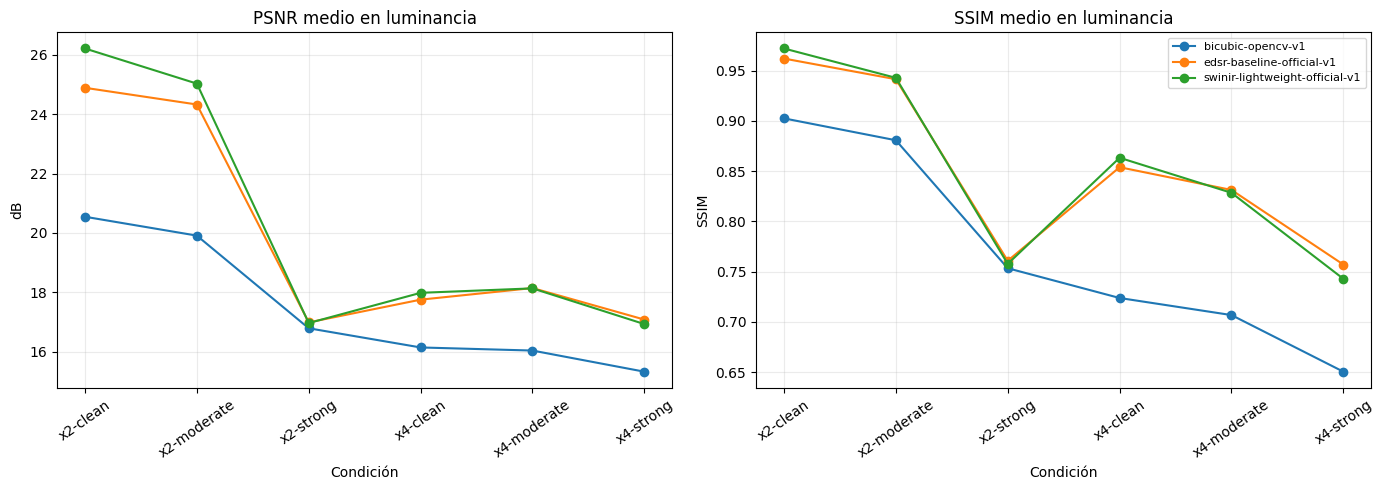

In [11]:
if not aggregate.empty:
    figure, axes = plt.subplots(1, 2, figsize=(14, 5))
    for method_id in MODEL_METHODS:
        frame = (
            aggregate[aggregate.method_id == method_id]
            .set_index("condition_id")
            .loc[list(CONDITIONS)]
            .reset_index()
        )
        axes[0].plot(frame.condition_id, frame.psnr_y_mean, marker="o", label=method_id)
        axes[1].plot(frame.condition_id, frame.ssim_y_mean, marker="o", label=method_id)
    axes[0].set(title="PSNR medio en luminancia", ylabel="dB", xlabel="Condición")
    axes[1].set(title="SSIM medio en luminancia", ylabel="SSIM", xlabel="Condición")
    for axis in axes:
        axis.tick_params(axis="x", rotation=35)
        axis.grid(alpha=0.25)
    axes[1].legend(fontsize=8)
    figure.tight_layout()
    figure.savefig(ARTIFACT_ROOT / "metrics-overview.png", dpi=220, bbox_inches="tight")
    plt.show()

## 6. Paquete descargable

Esta celda solo empaqueta una ejecución completa y reconciliada. El ZIP v2 no sobrescribe el paquete v1.

In [3]:
import hashlib
import json
import os
import platform
import shutil
import subprocess
from datetime import UTC, datetime
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
from IPython.display import FileLink, display

PROJECT_ROOT = Path("/kaggle/working/proyecto-tfg")
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts/phase3-smb-evaluation-v2"
RESULTS_PATH = ARTIFACT_ROOT / "raw-metrics.csv"
TRACES_PATH = ARTIFACT_ROOT / "degradation-traces.jsonl"
PREFLIGHT_PATH = ARTIFACT_ROOT / "staff-scale-preflight.csv"
SEED = 20260830
IS_KAGGLE = True

required = [RESULTS_PATH, TRACES_PATH, PREFLIGHT_PATH]
missing = [str(path) for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Faltan artefactos persistidos: {missing}")

CONDITIONS = {
    "x2-clean",
    "x2-moderate",
    "x2-strong",
    "x4-clean",
    "x4-moderate",
    "x4-strong",
}
MODEL_METHODS = {
    "bicubic-opencv-v1",
    "edsr-baseline-official-v1",
    "swinir-lightweight-official-v1",
}

results = pd.read_csv(RESULTS_PATH)
preflight = pd.read_csv(PREFLIGHT_PATH)
traces = [json.loads(line) for line in TRACES_PATH.read_text(encoding="utf-8").splitlines()]
qualitative_files = sorted((ARTIFACT_ROOT / "qualitative").rglob("*.png"))

keys = ["item_id", "condition_id", "method_id"]
metrics = ["psnr_y", "ssim_y", "psnr_rgb", "ssim_rgb"]

checks = {
    "rows_1152": len(results) == 1152,
    "unique_tuples_1152": len(results.drop_duplicates(keys)) == 1152,
    "pages_64": results.item_id.nunique() == 64,
    "works_64": results.source_group_id.nunique() == 64,
    "conditions_exact": set(results.condition_id) == CONDITIONS,
    "methods_exact": set(results.method_id) == MODEL_METHODS,
    "three_methods_per_case": (
        results.groupby(["item_id", "condition_id"]).method_id.nunique() == 3
    ).all(),
    "metrics_complete_and_finite": (
        not results[metrics].isna().any().any() and np.isfinite(results[metrics].to_numpy()).all()
    ),
    "ssim_in_range": (
        (results[["ssim_y", "ssim_rgb"]] <= 1).all().all()
        and (results[["ssim_y", "ssim_rgb"]] >= -1).all().all()
    ),
    "runtime_valid": (
        np.isfinite(results.runtime_seconds).all() and (results.runtime_seconds >= 0).all()
    ),
    "output_hashes_valid": results.output_sha256.str.fullmatch(r"[0-9a-f]{64}").all(),
    "degradation_traces_384": (
        len(traces) == 384 and len({trace["trace_id"] for trace in traces}) == 384
    ),
    "qualitative_pngs_30": len(qualitative_files) == 30,
    "preflight_identity_64_passed": (len(preflight) == 64 and preflight.identity_match.all()),
}
checks = {name: bool(value) for name, value in checks.items()}

if not all(checks.values()):
    raise RuntimeError(f"La ejecución persistida no está completa: {checks}")

aggregate = results.groupby(["condition_id", "method_id"], as_index=False).agg(
    pages=("item_id", "nunique"),
    psnr_y_mean=("psnr_y", "mean"),
    ssim_y_mean=("ssim_y", "mean"),
    psnr_rgb_mean=("psnr_rgb", "mean"),
    ssim_rgb_mean=("ssim_rgb", "mean"),
    runtime_seconds_median=("runtime_seconds", "median"),
)
aggregate.to_csv(ARTIFACT_ROOT / "aggregate-metrics.csv", index=False)

print(
    {
        "rows": len(results),
        "traces": len(traces),
        "qualitative_pngs": len(qualitative_files),
        "preflight_rows": len(preflight),
        "all_checks": all(checks.values()),
    }
)

{'rows': 1152, 'traces': 384, 'qualitative_pngs': 30, 'preflight_rows': 64, 'all_checks': True}


In [4]:
if results.empty:
    print("No hay una ejecución v2 completa que empaquetar.")
else:
    git_revision = subprocess.run(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"],
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
    runtime_evidence = {
        "recorded_at": datetime.now(UTC).isoformat(),
        "git_revision": git_revision,
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "opencv": cv2.__version__,
        "torch": torch.__version__,
        "cuda_runtime": torch.version.cuda,
        "cudnn": torch.backends.cudnn.version(),
        "gpu_devices": [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())],
        "seed": SEED,
        "validation": {name: bool(passed) for name, passed in checks.items()},
    }
    (ARTIFACT_ROOT / "runtime-evidence.json").write_text(
        json.dumps(runtime_evidence, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    freeze = subprocess.run(
        ["uv", "pip", "freeze", "--system"],
        check=True,
        capture_output=True,
        text=True,
    ).stdout
    (ARTIFACT_ROOT / "environment-freeze.txt").write_text(freeze, encoding="utf-8")

    frozen_inputs = ARTIFACT_ROOT / "frozen-inputs"
    frozen_inputs.mkdir(exist_ok=True)
    for relative in (
        "configs/experiments/smb-pretrained-evaluation-v2.yaml",
        "configs/degradations/staff-scale-score-v2.yaml",
        "data/audits/smb-evaluation-sample-v2.csv",
        "data/audits/smb-evaluation-v1-source-groups.csv",
        "data/manifests/smb-evaluation-v1.yaml",
        "data/sources/smb.yaml",
    ):
        source = PROJECT_ROOT / relative
        shutil.copy2(source, frozen_inputs / source.name)
    shutil.copytree(
        PROJECT_ROOT / "configs/smb-evaluation-v2",
        frozen_inputs / "smb-evaluation-v2",
        dirs_exist_ok=True,
    )

    def sha256_file(path: Path) -> str:
        with path.open("rb") as source:
            return hashlib.file_digest(source, "sha256").hexdigest()

    manifest = {
        str(path.relative_to(ARTIFACT_ROOT)): {
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in sorted(ARTIFACT_ROOT.rglob("*"))
        if path.is_file() and path.name != "artifact-manifest.json"
    }
    (ARTIFACT_ROOT / "artifact-manifest.json").write_text(
        json.dumps(manifest, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )

    archive_base = (
        Path("/kaggle/working/phase3-smb-evaluation-v2")
        if IS_KAGGLE
        else PROJECT_ROOT / "artifacts/phase3-smb-evaluation-v2"
    )
    archive_path = Path(shutil.make_archive(str(archive_base), "zip", ARTIFACT_ROOT))
    print(
        {
            "archive": str(archive_path),
            "bytes": archive_path.stat().st_size,
            "sha256": sha256_file(archive_path),
        }
    )
    if IS_KAGGLE:
        os.chdir("/kaggle/working")
        display(FileLink(archive_path.name))

{'archive': '/kaggle/working/phase3-smb-evaluation-v2.zip', 'bytes': 36739281, 'sha256': '18d904eda110c37cffb29674d04b11947bc49c5c37710fd9d74728cd185e499c'}


/kaggle/working/phase3-smb-evaluation-v2.zip

## Interpretación posterior

Después de descargar el ZIP se realizará el análisis estadístico y visual sin modificar el protocolo. Deben conservarse los ejemplos negativos, revisar explícitamente líneas de pentagrama, geometría de símbolos, uniones/separaciones, texto, cambios musicales plausibles y la textura o *ringing* introducidos por modelos entrenados con imágenes naturales.